In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense       

In [2]:
model = Sequential()  
model.add(Dense(4, activation='relu', input_shape=(2,)))   
model.add(Dense(8, activation='relu'))                     
model.add(Dense(3, activation='relu'))                     
model.add(Dense(3, activation='softmax'))                   

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

texts = [

    "guten morning is good morning",        
    "watches are good for your fitlook",       
    "pasta is tastly but unhealthy",           
    "Dance is hard",                           
    "SRH is Best uni",                         
    "german language is hard",                  
    "german movies are good",                   
    "many german movie has no action parts",    
    "i dont like to dance",                     
    "germany is good but weather is bad",       

    
    "i love german food",
    "SRH has great professors",
    "mannheim is a beautiful city",
    "i enjoy learning new languages",
    "the weather today is amazing",

    
    "this movie was really boring",
    "i hate waking up early",
    "the food was cold and tasteless",
    "german winters are too dark",
    "i dislike crowded places",

    
    "germany has many universities",
    "pasta is made from wheat",
    "dance is a form of exercise",
    "the movie was two hours long",
    "mannheim is a city in germany",
]

# Labels: 0 = Negative, 1 = Positive, 2 = Neutral 
labels = np.array([
    1, 1, 2, 0, 1, 0, 1, 0, 0, 2,
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0,
    2, 2, 2, 2, 2
])

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(texts).toarray()

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nNumeric representation:")
print(X)

model = Sequential()

model.add(Dense(25, activation='relu', input_shape=(X.shape[1],)))  # hidden layer 1
model.add(Dense(16, activation='relu'))                             # hidden layer 2 
model.add(Dense(3,  activation='softmax'))                          # output layer: 3 

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model
history = model.fit(X, labels,
                    epochs=100,  # number of full passes through the dataset
                    verbose=0)   # verbose=0 means no output during training

new_text = ["Indian's are bad in Hindi"]

new_vector = vectorizer.transform(new_text).toarray()

prediction = model.predict(new_vector)
predicted_class = np.argmax(prediction[0])

print("\nClass probabilities (Negative, Positive, Neutral):", prediction[0])

if predicted_class == 1:
    print("Positive Review")
elif predicted_class == 0:
    print("Negative Review")
else:
    print("Neutral Review")

Vocabulary:
['action' 'amazing' 'and' 'are' 'bad' 'beautiful' 'best' 'boring' 'but'
 'city' 'cold' 'crowded' 'dance' 'dark' 'dislike' 'dont' 'early' 'enjoy'
 'exercise' 'fitlook' 'food' 'for' 'form' 'from' 'german' 'germany' 'good'
 'great' 'guten' 'hard' 'has' 'hate' 'hours' 'in' 'is' 'language'
 'languages' 'learning' 'like' 'long' 'love' 'made' 'mannheim' 'many'
 'morning' 'movie' 'movies' 'new' 'no' 'of' 'parts' 'pasta' 'places'
 'professors' 'really' 'srh' 'tasteless' 'tastly' 'the' 'this' 'to'
 'today' 'too' 'two' 'unhealthy' 'uni' 'universities' 'up' 'waking' 'was'
 'watches' 'weather' 'wheat' 'winters' 'your']

Numeric representation:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.43848919]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 25)             │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,367 (9.25 KB)

 Trainable params: 2,367 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Class probabilities (Negative, Positive, Neutral): [0.42817956 0.25111714 0.32070327]
Negative Review


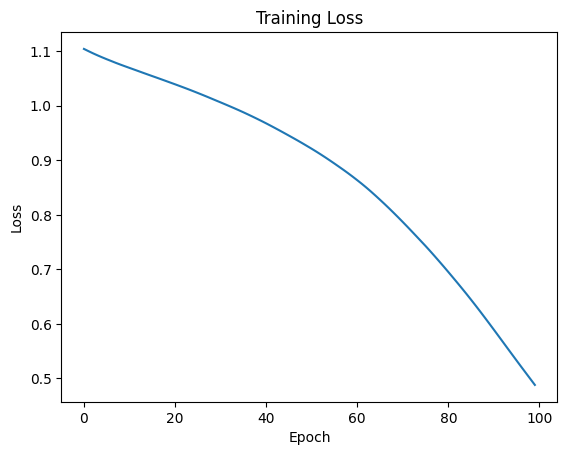

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


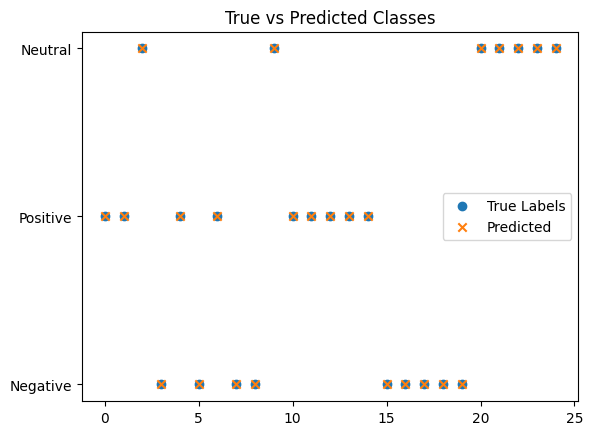

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

predictions = model.predict(X)
predicted_classes = np.argmax(predictions, axis=1)  

plt.scatter(range(len(labels)), labels, label='True Labels', marker='o')
plt.scatter(range(len(predicted_classes)), predicted_classes, label='Predicted', marker='x')
plt.legend()
plt.title('True vs Predicted Classes')
plt.yticks([0, 1, 2], ['Negative', 'Positive', 'Neutral'])
plt.show()